# 🎓 THESIS PROJECT: VISUAL ANOMALY DETECTION
## NOTEBOOK 3: SSIM STRUCTURAL RECONSTRUCTION ANALYSIS

### Objective
This notebook extends the reconstruction study from Notebook 2 by evaluating whether **structural similarity** provides a more informative anomaly score than pixel-wise reconstruction MSE for the same frozen tuned convolutional autoencoder.

Notebook 2 established the reconstruction model and locked its parameters. Notebook 3 does **not** re-train or redesign that model. Instead, it changes the way reconstruction failure is measured.

### Experimental contract
- **Upstream dependency:** the finalized Notebook 2 experiment contract and `tuned_conv_ae.keras`.
- **Model state:** frozen; no training or fine-tuning occurs in this notebook.
- **Dataset/preprocessing:** identical MVTec AD `bottle`, `128 × 128` RGB tensors normalized to `[0, 1]`.
- **Label contract:** `0 = good`, `1 = anomaly`.
- **Notebook-wide anomaly-score contract:** **higher score = more anomalous**.
- **MSE score:** per-image reconstruction MSE.
- **SSIM similarity:** higher value = structurally more similar.
- **SSIM anomaly score:** `1 - SSIM`, therefore higher value = more structurally anomalous.
- **Threshold calibration:** normal calibration subset inherited deterministically from the Notebook 2 development split.
- **Final test benchmark:** the same locked MVTec test partition used for cross-notebook comparability; it is used only for evaluation and never for fitting, calibration, score-direction selection or model redesign.

### Research question
> **For the same frozen reconstruction model and the same images, does an SSIM-derived structural anomaly score provide better anomaly ranking than pixel-wise MSE?**

The original Gaussian-noise and illumination experiment is retained as a **secondary SSIM sensitivity diagnostic**, not as the main anomaly-detection experiment and not as an arbitrary augmentation “safety gate”.


### BLOCK 1: IMPORT LIBRARIES & GLOBAL CONFIGURATION

**OBJECTIVE:**  
Initialize the structural-analysis environment while preserving the same core experiment contract used in Notebooks 1 and 2.

**SHARED CONTRACT:**
- `IMG_SIZE = (128, 128)`
- `TARGET_CLASS = "bottle"`
- `SEED = 42`
- `NORMAL_LABEL = 0`, `ANOMALY_LABEL = 1`
- `VALIDATION_FRACTION = 0.20`
- `TARGET_VALIDATION_FPR = 0.05`
- deterministic data splitting and normalized RGB tensors

**NOTEBOOK 3 EXTENSIONS:**
- `skimage.metrics.structural_similarity`
- frozen Notebook 2 model import
- SSIM-derived anomaly scoring
- controlled SSIM sensitivity analysis for Gaussian noise and illumination changes


In [1]:
# ==========================================================================================================================================================
# BLOCK 1: IMPORT LIBRARIES & GLOBAL CONFIGURATION
# ==========================================================================================================================================================

print("INITIALIZING SSIM STRUCTURAL ANALYSIS ENVIRONMENT...\n")
print("ACTION: Loading shared experiment contracts, TensorFlow inference support and SSIM analysis utilities.\n")


# REQUIRED MODULE IMPORTS

import json
import random
import tarfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)

from skimage.metrics import structural_similarity
from tensorflow.keras.utils import img_to_array, load_img


# SHARED GLOBAL CONFIGURATION

SEED = 42
IMG_SIZE = (128, 128)
TARGET_CLASS = "bottle"

NORMAL_LABEL = 0
ANOMALY_LABEL = 1

VALIDATION_FRACTION = 0.20
TARGET_VALIDATION_FPR = 0.05

IMAGE_EXTENSIONS = {".png"}

KAGGLE_INPUT_ROOT = Path("/kaggle/input")
KAGGLE_WORK_ROOT = Path("/kaggle/working")
KAGGLE_TEMP_ROOT = Path("/kaggle/temp")

PREFERRED_ARCHIVE_NAME = "mvtec_anomaly_detection.tar.xz"

DATASET_TEMP_ROOT = KAGGLE_TEMP_ROOT / "mvtec_ad_notebook3"

NOTEBOOK2_METRICS_FILENAME = "notebook2_metrics.json"
EXPECTED_NOTEBOOK2_SCHEMA = "2.1"
EXPECTED_NOTEBOOK2_ROLE = "controlled_autoencoder_tuning"

NOTEBOOK3_ARTIFACT_DIR = KAGGLE_WORK_ROOT / "notebook3_artifacts"
NOTEBOOK3_METRICS_PATH = KAGGLE_WORK_ROOT / "notebook3_metrics.json"


# NOTEBOOK 3 ANALYSIS CONFIGURATION

TUNING_VALIDATION_FRACTION = 0.50

NOISE_VARIANCES = (
    0.001,
    0.002,
    0.005,
    0.010,
    0.020,
    0.050,
    0.100,
)

BRIGHTNESS_FACTORS = (
    1.0,
    0.9,
    0.8,
    0.7,
    0.6,
    0.5,
    0.4,
    0.3,
)

SENSITIVITY_SAMPLE_COUNT = 12
RESIDUAL_DISPLAY_QUANTILE = 0.99


# REPRODUCIBILITY CONFIGURATION

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()


# CONFIGURATION INTEGRITY CHECKS

if not isinstance(IMG_SIZE, tuple) or len(IMG_SIZE) != 2 or any(int(v) <= 0 for v in IMG_SIZE):
    raise ValueError(
        f"BLOCK 1 CONFIGURATION FAILURE: invalid IMG_SIZE={IMG_SIZE!r}"
    )

if not (0.0 < VALIDATION_FRACTION < 1.0):
    raise ValueError(
        "BLOCK 1 CONFIGURATION FAILURE: VALIDATION_FRACTION must be between 0 and 1."
    )

if not (0.0 < TUNING_VALIDATION_FRACTION < 1.0):
    raise ValueError(
        "BLOCK 1 CONFIGURATION FAILURE: TUNING_VALIDATION_FRACTION must be between 0 and 1."
    )

if not (0.0 < TARGET_VALIDATION_FPR < 1.0):
    raise ValueError(
        "BLOCK 1 CONFIGURATION FAILURE: TARGET_VALIDATION_FPR must be between 0 and 1."
    )

if not (0.0 < RESIDUAL_DISPLAY_QUANTILE < 1.0):
    raise ValueError(
        "BLOCK 1 CONFIGURATION FAILURE: RESIDUAL_DISPLAY_QUANTILE must be between 0 and 1."
    )

if SENSITIVITY_SAMPLE_COUNT <= 0:
    raise ValueError(
        "BLOCK 1 CONFIGURATION FAILURE: SENSITIVITY_SAMPLE_COUNT must be positive."
    )


print("CONFIGURATION SUMMARY")
print(f"  Target class               : {TARGET_CLASS}")
print(f"  Image size                 : {IMG_SIZE}")
print(f"  Random seed                : {SEED}")
print(f"  Outer validation fraction  : {VALIDATION_FRACTION:.0%}")
print(f"  Tuning share of val pool   : {TUNING_VALIDATION_FRACTION:.0%}")
print(f"  Target calibration FPR     : {TARGET_VALIDATION_FPR:.0%}")
print(f"  Sensitivity sample count   : {SENSITIVITY_SAMPLE_COUNT}")

print("\n✅ BLOCK 1 COMPLETED: Structural-analysis environment initialized.")


INITIALIZING SSIM STRUCTURAL ANALYSIS ENVIRONMENT...

ACTION: Loading shared experiment contracts, TensorFlow inference support and SSIM analysis utilities.

CONFIGURATION SUMMARY
  Target class               : bottle
  Image size                 : (128, 128)
  Random seed                : 42
  Outer validation fraction  : 20%
  Tuning share of val pool   : 50%
  Target calibration FPR     : 5%
  Sensitivity sample count   : 12

✅ BLOCK 1 COMPLETED: Structural-analysis environment initialized.


### BLOCK 2: DATASET DISCOVERY, EXTRACTION & PATH RESOLUTION

**OBJECTIVE:**  
Resolve the canonical MVTec AD `bottle` dataset while excluding upstream notebook-output copies as image-data sources.

Notebook 3 mounts the saved output of Notebook 2 in order to load its model and metric contract. That output must **not** become the source of the raw MVTec images.

**DISCOVERY STRATEGY:**
1. Reuse a valid temporary extraction from the current session.
2. Search directly mounted non-notebook Kaggle inputs for the target class.
3. Search those canonical inputs for a compatible MVTec archive.
4. Extract only to `/kaggle/temp`.
5. Validate the final class structure before continuing.

The dataset identity and preprocessing semantics remain aligned with Notebooks 1 and 2.


In [2]:
# ==========================================================================================================================================================
# BLOCK 2: DATASET DISCOVERY, EXTRACTION & PATH RESOLUTION
# ==========================================================================================================================================================

print("RESOLVING MVTEC DATASET STRUCTURE...\n")
print("ACTION: Locating the canonical MVTec input while excluding upstream notebook-output copies.\n")


# UPSTREAM DEPENDENCY AUDIT

_required_block_2_objects = [
    "KAGGLE_INPUT_ROOT",
    "DATASET_TEMP_ROOT",
    "TARGET_CLASS",
    "PREFERRED_ARCHIVE_NAME",
]

_missing_block_2_objects = [
    object_name
    for object_name in _required_block_2_objects
    if object_name not in globals() or globals()[object_name] is None
]

if _missing_block_2_objects:
    raise RuntimeError(
        "BLOCK 2 DEPENDENCY FAILURE: missing upstream objects: "
        f"{_missing_block_2_objects}. Run Block 1 first."
    )


# DATASET DISCOVERY HELPERS

def is_valid_mvtec_class_dir(candidate):
    """Return True when a directory satisfies the minimum MVTec class contract."""

    candidate = Path(candidate)

    return (
        candidate.is_dir()
        and (candidate / "train" / "good").is_dir()
        and (candidate / "test" / "good").is_dir()
    )


def find_target_class_dir(search_root):
    """Search one root for the requested MVTec class."""

    search_root = Path(search_root)

    if not search_root.is_dir():
        return None

    direct_candidates = [
        search_root / TARGET_CLASS,
        search_root / "mvtec_anomaly_detection" / TARGET_CLASS,
        search_root / "mvtec_ad" / TARGET_CLASS,
        search_root / "mvtec-ad" / TARGET_CLASS,
    ]

    for candidate in direct_candidates:
        if is_valid_mvtec_class_dir(candidate):
            return candidate

    candidate_dirs = sorted(
        (
            path
            for path in search_root.rglob(TARGET_CLASS)
            if path.is_dir()
        ),
        key=lambda path: (
            len(path.parts),
            str(path),
        ),
    )

    for candidate in candidate_dirs:
        if is_valid_mvtec_class_dir(candidate):
            return candidate

    return None


def raw_kaggle_input_roots():
    """
    Return top-level Kaggle inputs that are not notebook-output mounts.

    Saved Kaggle notebook outputs are mounted under /kaggle/input/notebooks
    in the current workflow and must not become the image-data source.
    """

    if not KAGGLE_INPUT_ROOT.is_dir():
        return []

    return [
        path
        for path in sorted(
            KAGGLE_INPUT_ROOT.iterdir(),
            key=str,
        )
        if path.name != "notebooks"
    ]


def discover_mvtec_archive(search_roots):
    """Return the most plausible MVTec archive from canonical input roots."""

    archives = []

    for search_root in search_roots:

        if not Path(search_root).is_dir():
            continue

        archives.extend(
            path
            for path in Path(search_root).rglob("*.tar.xz")
            if path.is_file()
        )

    archives = sorted(
        set(archives),
        key=str,
    )

    if not archives:
        return None

    def archive_rank(path):

        name = path.name.lower()
        parent_text = str(path.parent).lower()

        exact_name = int(
            name == PREFERRED_ARCHIVE_NAME.lower()
        )

        mentions_mvtec = int(
            "mvtec" in name
            or "mvtec" in parent_text
        )

        mentions_target = int(
            TARGET_CLASS.lower() in name
        )

        return (
            -exact_name,
            -mentions_mvtec,
            -mentions_target,
            len(path.parts),
            str(path),
        )

    return sorted(
        archives,
        key=archive_rank,
    )[0]


# STAGE 1: REUSE TEMPORARY EXTRACTION FROM THIS SESSION

BASE_DIR = find_target_class_dir(
    DATASET_TEMP_ROOT
)

dataset_source = (
    "session_temp"
    if BASE_DIR is not None
    else None
)


# STAGE 2: SEARCH CANONICAL NON-NOTEBOOK INPUTS

raw_input_roots = raw_kaggle_input_roots()

if BASE_DIR is None:

    direct_matches = []

    for search_root in raw_input_roots:

        candidate = find_target_class_dir(
            search_root
        )

        if candidate is not None:
            direct_matches.append(
                candidate
            )

    if direct_matches:

        BASE_DIR = sorted(
            direct_matches,
            key=lambda path: (
                len(path.parts),
                str(path),
            ),
        )[0]

        dataset_source = "canonical_kaggle_input"


# STAGE 3: DISCOVER AND EXTRACT ARCHIVE TO /kaggle/temp

if BASE_DIR is None:

    archive_path = discover_mvtec_archive(
        raw_input_roots
    )

    if archive_path is None:

        mounted_entries = (
            sorted(
                path.name
                for path in KAGGLE_INPUT_ROOT.iterdir()
            )
            if KAGGLE_INPUT_ROOT.is_dir()
            else []
        )

        raise FileNotFoundError(
            "BLOCK 2 DATASET FAILURE: no valid canonical MVTec "
            f"'{TARGET_CLASS}' directory or compatible .tar.xz archive was found "
            "outside notebook-output mounts. "
            f"Mounted input entries: {mounted_entries}. "
            "Attach the MVTec AD dataset independently of the Notebook 1 output."
        )

    DATASET_TEMP_ROOT.mkdir(
        parents=True,
        exist_ok=True,
    )

    print(
        f"Discovered dataset archive: {archive_path}"
    )

    print(
        f"Extracting archive to temporary session storage: {DATASET_TEMP_ROOT}\n"
    )

    with tarfile.open(
        archive_path,
        mode="r:*",
    ) as archive:

        archive.extractall(
            DATASET_TEMP_ROOT,
            filter="data",
        )

    BASE_DIR = find_target_class_dir(
        DATASET_TEMP_ROOT
    )

    dataset_source = "canonical_archive_temp_extraction"


# FINAL DATASET CONTRACT VALIDATION

if BASE_DIR is None or not is_valid_mvtec_class_dir(BASE_DIR):
    raise RuntimeError(
        "BLOCK 2 DATASET FAILURE: dataset discovery/extraction completed, "
        f"but a valid '{TARGET_CLASS}' MVTec class structure could not be resolved."
    )


TRAIN_GOOD_DIR = BASE_DIR / "train" / "good"
TEST_DIR = BASE_DIR / "test"
TEST_GOOD_DIR = TEST_DIR / "good"

defect_categories = sorted(
    path.name
    for path in TEST_DIR.iterdir()
    if path.is_dir()
    and path.name != "good"
)

if not defect_categories:
    raise RuntimeError(
        "BLOCK 2 DATASET FAILURE: the resolved test directory contains no defective categories."
    )


print("DATASET RESOLUTION SUMMARY")
print(f"  Source mode       : {dataset_source}")
print(f"  Resolved class dir: {BASE_DIR}")
print(f"  Train/good        : {TRAIN_GOOD_DIR}")
print(f"  Test/good         : {TEST_GOOD_DIR}")
print(f"  Defect categories : {defect_categories}")

print("\n✅ BLOCK 2 COMPLETED: Canonical dataset source resolved and validated.")


RESOLVING MVTEC DATASET STRUCTURE...

ACTION: Locating the canonical MVTec input while excluding upstream notebook-output copies.

Discovered dataset archive: /kaggle/input/datasets/chrysoulatsitsifa/mvtec-ad-dataset/mvtec_anomaly_detection.tar.xz
Extracting archive to temporary session storage: /kaggle/temp/mvtec_ad_notebook3

DATASET RESOLUTION SUMMARY
  Source mode       : canonical_archive_temp_extraction
  Resolved class dir: /kaggle/temp/mvtec_ad_notebook3/bottle
  Train/good        : /kaggle/temp/mvtec_ad_notebook3/bottle/train/good
  Test/good         : /kaggle/temp/mvtec_ad_notebook3/bottle/test/good
  Defect categories : ['broken_large', 'broken_small', 'contamination']

✅ BLOCK 2 COMPLETED: Canonical dataset source resolved and validated.


### BLOCK 3: DATA LOADING, VALIDATION & SHARED SPLIT REPRODUCTION

**OBJECTIVE:**  
Load the same normalized MVTec tensors used by Notebook 2 and deterministically reproduce its development partition.

**SHARED DATA CONTRACT:**
- normal-only outer train/validation split with `SEED = 42`;
- final test set containing `test/good` plus all defect categories;
- RGB `float32` tensors normalized to `[0, 1]`;
- `0 = good`, `1 = anomaly`.

**NOTEBOOK 2 DEVELOPMENT PARTITION REPRODUCTION:**
The outer validation pool is split again using the same deterministic rule as Notebook 2:
- `tuning_validation_images`: development analysis / model-selection subset;
- `calibration_images`: normal-only score-threshold calibration subset.

This reproduction is verified against the imported Notebook 2 contract in Block 4.


In [3]:
# ==========================================================================================================================================================
# BLOCK 3: DATA LOADING, VALIDATION & SPLIT DEFINITION
# ==========================================================================================================================================================

print("EXECUTING DATA INGESTION & VALIDATION PIPELINE...\n")
print("ACTION: Loading images, preserving defect categories and establishing train/validation/test contracts.\n")


def load_image_directory(folder_path):
    """Load one image directory into a deterministic float32 RGB tensor."""

    folder_path = Path(folder_path)

    if not folder_path.is_dir():
        raise FileNotFoundError(f"Image directory does not exist: {folder_path}")

    image_paths = sorted(
        path
        for path in folder_path.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )

    if not image_paths:
        raise RuntimeError(f"No supported images found in: {folder_path}")

    images = np.empty(
        (len(image_paths), IMG_SIZE[0], IMG_SIZE[1], 3),
        dtype=np.float32,
    )

    for index, image_path in enumerate(image_paths):
        image = load_img(image_path, target_size=IMG_SIZE, color_mode="rgb")
        image = img_to_array(image).astype(np.float32) / 255.0
        images[index] = image

    return images, [str(path) for path in image_paths]


def validate_image_batch(batch_name, images):
    """Validate tensor schema and numerical range for one image batch."""

    expected_tail = (IMG_SIZE[0], IMG_SIZE[1], 3)

    if not isinstance(images, np.ndarray):
        raise TypeError(f"{batch_name}: expected numpy.ndarray, received {type(images).__name__}.")

    if images.ndim != 4 or tuple(images.shape[1:]) != expected_tail:
        raise ValueError(
            f"{batch_name}: expected shape (N, {expected_tail}), received {images.shape}."
        )

    if len(images) == 0:
        raise ValueError(f"{batch_name}: batch is empty.")

    if images.dtype != np.float32:
        raise TypeError(f"{batch_name}: expected float32, received {images.dtype}.")

    if not np.isfinite(images).all():
        raise ValueError(f"{batch_name}: NaN or infinite values detected.")

    if float(images.min()) < 0.0 or float(images.max()) > 1.0:
        raise ValueError(f"{batch_name}: normalized pixel values must remain inside [0, 1].")


# LOAD NORMAL TRAINING POOL

train_pool_images, train_pool_paths = load_image_directory(TRAIN_GOOD_DIR)
test_good, test_good_paths = load_image_directory(TEST_GOOD_DIR)


# LOAD ALL DEFECT CATEGORIES WHILE PRESERVING CATEGORY IDENTITY

test_bad_batches = []
test_bad_paths = []
test_bad_categories_list = []

dataset_rows = [
    {"split": "train", "category": "good", "samples": len(train_pool_images)},
    {"split": "test", "category": "good", "samples": len(test_good)},
]

for category in defect_categories:

    category_images, category_paths = load_image_directory(TEST_DIR / category)

    test_bad_batches.append(category_images)
    test_bad_paths.extend(category_paths)
    test_bad_categories_list.extend([category] * len(category_images))

    dataset_rows.append(
        {"split": "test", "category": category, "samples": len(category_images)}
    )

test_bad = np.concatenate(test_bad_batches, axis=0).astype(np.float32, copy=False)
test_bad_categories = np.asarray(test_bad_categories_list, dtype=object)


# NORMAL-ONLY TRAIN / VALIDATION SPLIT

train_indices, validation_indices = train_test_split(
    np.arange(len(train_pool_images)),
    test_size=VALIDATION_FRACTION,
    random_state=SEED,
    shuffle=True,
)

train_images = train_pool_images[train_indices]
validation_images = train_pool_images[validation_indices]

train_paths = [train_pool_paths[index] for index in train_indices]
validation_paths = [train_pool_paths[index] for index in validation_indices]


# FINAL TEST CONTRACT

test_images = np.concatenate((test_good, test_bad), axis=0).astype(np.float32, copy=False)

test_labels = np.concatenate(
    (
        np.full(len(test_good), NORMAL_LABEL, dtype=np.int8),
        np.full(len(test_bad), ANOMALY_LABEL, dtype=np.int8),
    )
)

test_categories = np.concatenate(
    (
        np.full(len(test_good), "good", dtype=object),
        test_bad_categories,
    )
)


# DATA INTEGRITY AUDIT

for batch_name, images in {
    "train_images": train_images,
    "validation_images": validation_images,
    "test_good": test_good,
    "test_bad": test_bad,
    "test_images": test_images,
}.items():
    validate_image_batch(batch_name, images)

if len(test_images) != len(test_labels) or len(test_images) != len(test_categories):
    raise RuntimeError("BLOCK 3 CONTRACT FAILURE: test image/label/category lengths are inconsistent.")

if set(np.unique(test_labels)) != {NORMAL_LABEL, ANOMALY_LABEL}:
    raise RuntimeError("BLOCK 3 CONTRACT FAILURE: final test set does not contain both label classes.")


dataset_audit = pd.DataFrame(dataset_rows)
dataset_audit["share_of_split"] = (
    dataset_audit["samples"]
    / dataset_audit.groupby("split")["samples"].transform("sum")
)

split_audit = pd.DataFrame(
    [
        {"data_object": "train_images", "role": "normal-only model fitting", "samples": len(train_images)},
        {"data_object": "validation_images", "role": "shared normal development-validation pool", "samples": len(validation_images)},
        {"data_object": "test_good", "role": "final normal evaluation", "samples": len(test_good)},
        {"data_object": "test_bad", "role": "final anomaly evaluation", "samples": len(test_bad)},
    ]
)

print("DATASET CATEGORY AUDIT")
display(dataset_audit)

print("\nEXPERIMENT SPLIT AUDIT")
display(split_audit)

print(
    f"\nTensor contract: {IMG_SIZE[0]}x{IMG_SIZE[1]}x3, "
    f"dtype={train_images.dtype}, range=[{train_images.min():.3f}, {train_images.max():.3f}]"
)



# NOTEBOOK 2 INNER DEVELOPMENT PARTITION REPRODUCTION

validation_pool_indices = np.arange(
    len(validation_images)
)

tuning_validation_indices, calibration_indices = train_test_split(
    validation_pool_indices,
    test_size=1.0 - TUNING_VALIDATION_FRACTION,
    random_state=SEED,
    shuffle=True,
)

tuning_validation_images = validation_images[
    tuning_validation_indices
]

calibration_images = validation_images[
    calibration_indices
]

if (
    len(tuning_validation_images) == 0
    or len(calibration_images) == 0
):
    raise RuntimeError(
        "BLOCK 3 SPLIT FAILURE: tuning-validation and calibration subsets must both be non-empty."
    )

if set(tuning_validation_indices.tolist()).intersection(calibration_indices.tolist()):
    raise RuntimeError(
        "BLOCK 3 SPLIT FAILURE: reproduced tuning-validation and calibration indices overlap."
    )


development_summary = pd.DataFrame(
    [
        {
            "data_object": "train_images",
            "role": "Notebook 2 model-fitting subset",
            "samples": int(len(train_images)),
            "mean_pixel": float(train_images.mean()),
            "std_pixel": float(train_images.std()),
        },
        {
            "data_object": "tuning_validation_images",
            "role": "Notebook 2 tuning-validation subset",
            "samples": int(len(tuning_validation_images)),
            "mean_pixel": float(tuning_validation_images.mean()),
            "std_pixel": float(tuning_validation_images.std()),
        },
        {
            "data_object": "calibration_images",
            "role": "normal-only score calibration",
            "samples": int(len(calibration_images)),
            "mean_pixel": float(calibration_images.mean()),
            "std_pixel": float(calibration_images.std()),
        },
    ]
)

print("\nREPRODUCED DEVELOPMENT PARTITION")
display(development_summary)

print(
    "\n✅ BLOCK 3 COMPLETED: Notebook 2 development partition reproduced deterministically."
)


EXECUTING DATA INGESTION & VALIDATION PIPELINE...

ACTION: Loading images, preserving defect categories and establishing train/validation/test contracts.

DATASET CATEGORY AUDIT


,split,category,samples,share_of_split
0,train,good,209,1.000000
1,test,good,20,0.240964
2,test,broken_large,20,0.240964
3,test,broken_small,22,0.265060
4,test,contamination,21,0.253012



EXPERIMENT SPLIT AUDIT


,data_object,role,samples
0,train_images,normal-only model fitting,167
1,validation_images,shared normal development-validation pool,42
2,test_good,final normal evaluation,20
3,test_bad,final anomaly evaluation,63



Tensor contract: 128x128x3, dtype=float32, range=[0.098, 1.000]

REPRODUCED DEVELOPMENT PARTITION


,data_object,role,samples,mean_pixel,std_pixel
0,train_images,Notebook 2 model-fitting subset,167,0.538412,0.361365
1,tuning_validation_images,Notebook 2 tuning-validation subset,21,0.540404,0.360719
2,calibration_images,normal-only score calibration,21,0.539007,0.361560



✅ BLOCK 3 COMPLETED: Notebook 2 development partition reproduced deterministically.


### BLOCK 4: NOTEBOOK 2 MODEL & EXPERIMENT CONTRACT IMPORT

**OBJECTIVE:**  
Load the frozen Tuned Conv AE produced by Notebook 2 and verify that it belongs to the same experiment reproduced in Blocks 1–3.

**STRICT CONTRACT GATES:**
- Notebook 2 schema and experiment role;
- target class, image size, seed, labels and score direction;
- train/validation/calibration/test sample counts;
- defect-category counts;
- locked score-direction policy;
- canonical `conv_ae` reference metric;
- existence and tensor compatibility of the exported `tuned_conv_ae.keras` artifact.

Notebook 3 never re-trains this model. It treats the upstream model as immutable experimental evidence.


In [4]:
# ==========================================================================================================================================================
# BLOCK 4: NOTEBOOK 2 MODEL & EXPERIMENT CONTRACT IMPORT
# ==========================================================================================================================================================

print("LOADING NOTEBOOK 2 EXPERIMENT CONTRACT...\n")
print("ACTION: Strictly validating the upstream tuning experiment and loading its frozen model artifact.\n")


# UPSTREAM DEPENDENCY AUDIT

_required_block_4_objects = [
    "KAGGLE_INPUT_ROOT",
    "NOTEBOOK2_METRICS_FILENAME",
    "EXPECTED_NOTEBOOK2_SCHEMA",
    "EXPECTED_NOTEBOOK2_ROLE",
    "TARGET_CLASS",
    "IMG_SIZE",
    "SEED",
    "NORMAL_LABEL",
    "ANOMALY_LABEL",
    "train_images",
    "validation_images",
    "tuning_validation_images",
    "calibration_images",
    "test_good",
    "test_bad",
    "test_bad_categories",
]

_missing_block_4_objects = [
    object_name
    for object_name in _required_block_4_objects
    if object_name not in globals() or globals()[object_name] is None
]

if _missing_block_4_objects:
    raise RuntimeError(
        "BLOCK 4 DEPENDENCY FAILURE: missing upstream objects: "
        f"{_missing_block_4_objects}. Run the notebook sequentially from Block 1."
    )


# CURRENT NOTEBOOK 3 DATA CONTRACT

current_defect_counts = {
    str(category): int(
        np.sum(
            test_bad_categories == category
        )
    )
    for category in sorted(
        np.unique(
            test_bad_categories
        )
    )
}

expected_notebook2_dataset = {
    "train_normal": int(len(train_images)),
    "outer_validation_normal": int(len(validation_images)),
    "tuning_validation_normal": int(len(tuning_validation_images)),
    "calibration_normal": int(len(calibration_images)),
    "test_normal": int(len(test_good)),
    "test_anomaly": int(len(test_bad)),
    "test_defect_categories": current_defect_counts,
}


# CONTRACT DISCOVERY

contract_candidates = sorted(
    path
    for path in KAGGLE_INPUT_ROOT.rglob(
        NOTEBOOK2_METRICS_FILENAME
    )
    if path.is_file()
)

validated_contracts = []
rejected_contracts = []


for candidate_path in contract_candidates:

    try:
        with candidate_path.open(
            "r",
            encoding="utf-8",
        ) as file:
            candidate = json.load(file)

    except Exception as exc:
        rejected_contracts.append(
            {
                "path": str(candidate_path),
                "reason": f"unreadable JSON: {exc}",
            }
        )
        continue


    rejection_reasons = []


    if candidate.get("schema_version") != EXPECTED_NOTEBOOK2_SCHEMA:
        rejection_reasons.append("schema_version")

    if candidate.get("experiment_role") != EXPECTED_NOTEBOOK2_ROLE:
        rejection_reasons.append("experiment_role")

    if candidate.get("target_class") != TARGET_CLASS:
        rejection_reasons.append("target_class")

    if candidate.get("img_size") != list(IMG_SIZE):
        rejection_reasons.append("img_size")

    if candidate.get("seed") != SEED:
        rejection_reasons.append("seed")

    if candidate.get("label_contract") != {
        "good": NORMAL_LABEL,
        "anomaly": ANOMALY_LABEL,
    }:
        rejection_reasons.append("label_contract")

    if candidate.get("score_contract") != "higher_score_means_more_anomalous":
        rejection_reasons.append("score_contract")

    if candidate.get("score_direction_locked_before_test") is not True:
        rejection_reasons.append("score_direction_lock")

    if candidate.get("dataset_summary") != expected_notebook2_dataset:
        rejection_reasons.append("dataset_summary")

    if "conv_ae" not in candidate:
        rejection_reasons.append("conv_ae")

    artifacts = candidate.get(
        "artifacts",
        {},
    )

    if "tuned_model" not in artifacts:
        rejection_reasons.append("tuned_model_artifact")


    if rejection_reasons:
        rejected_contracts.append(
            {
                "path": str(candidate_path),
                "reason": ", ".join(rejection_reasons),
            }
        )
        continue


    validated_contracts.append(
        (
            candidate_path,
            candidate,
        )
    )


if not validated_contracts:

    if rejected_contracts:
        print("REJECTED NOTEBOOK 2 CONTRACTS")
        display(pd.DataFrame(rejected_contracts))

    raise FileNotFoundError(
        "BLOCK 4 UPSTREAM FAILURE: no Notebook 2 contract matched the current "
        "Notebook 3 experiment. Attach the finalized Notebook 2 output."
    )


if len(validated_contracts) > 1:
    raise RuntimeError(
        "BLOCK 4 UPSTREAM FAILURE: multiple fully compatible Notebook 2 contracts were found. "
        "Attach only the intended finalized Notebook 2 output. "
        f"Candidates: {[str(path) for path, _ in validated_contracts]}"
    )


NOTEBOOK2_METRICS_PATH = validated_contracts[0][0]
notebook2_contract = validated_contracts[0][1]

notebook2_mse_auc = float(
    notebook2_contract["conv_ae"]
)

if not np.isfinite(notebook2_mse_auc) or not (0.0 <= notebook2_mse_auc <= 1.0):
    raise ValueError(
        f"BLOCK 4 UPSTREAM FAILURE: invalid Notebook 2 conv_ae ROC-AUC={notebook2_mse_auc!r}"
    )


# PORTABLE MODEL ARTIFACT RESOLUTION

tuned_model_relative_path = notebook2_contract[
    "artifacts"
][
    "tuned_model"
]

TUNED_MODEL_PATH = (
    NOTEBOOK2_METRICS_PATH.parent
    / tuned_model_relative_path
).resolve()


if not TUNED_MODEL_PATH.is_file():
    raise FileNotFoundError(
        "BLOCK 4 ARTIFACT FAILURE: Notebook 2 tuned-model artifact was not found at "
        f"{TUNED_MODEL_PATH}"
    )


tuned_model = tf.keras.models.load_model(
    TUNED_MODEL_PATH
)


# MODEL TENSOR CONTRACT

expected_model_shape = (
    None,
    IMG_SIZE[0],
    IMG_SIZE[1],
    3,
)

if tuned_model.input_shape != expected_model_shape:
    raise RuntimeError(
        "BLOCK 4 MODEL FAILURE: upstream model input shape mismatch. "
        f"Expected {expected_model_shape}, received {tuned_model.input_shape}."
    )

if tuned_model.output_shape != expected_model_shape:
    raise RuntimeError(
        "BLOCK 4 MODEL FAILURE: upstream model output shape mismatch. "
        f"Expected {expected_model_shape}, received {tuned_model.output_shape}."
    )


best_batch_size = int(
    notebook2_contract[
        "optimization"
    ][
        "best_batch_size"
    ]
)


contract_audit = pd.DataFrame(
    [
        {
            "contract_field": "schema_version",
            "expected": EXPECTED_NOTEBOOK2_SCHEMA,
            "resolved": notebook2_contract["schema_version"],
            "status": "MATCH",
        },
        {
            "contract_field": "experiment_role",
            "expected": EXPECTED_NOTEBOOK2_ROLE,
            "resolved": notebook2_contract["experiment_role"],
            "status": "MATCH",
        },
        {
            "contract_field": "dataset_summary",
            "expected": str(expected_notebook2_dataset),
            "resolved": str(notebook2_contract["dataset_summary"]),
            "status": "MATCH",
        },
        {
            "contract_field": "score_direction_locked_before_test",
            "expected": True,
            "resolved": notebook2_contract["score_direction_locked_before_test"],
            "status": "MATCH",
        },
    ]
)


print(f"Resolved Notebook 2 contract: {NOTEBOOK2_METRICS_PATH}")
print(f"Resolved frozen model        : {TUNED_MODEL_PATH}")

display(contract_audit)

print(
    f"\nNotebook 2 reference MSE ROC-AUC: {notebook2_mse_auc:.6f}"
)

print(
    "\n✅ BLOCK 4 COMPLETED: Frozen Notebook 2 model and experiment contract verified."
)


LOADING NOTEBOOK 2 EXPERIMENT CONTRACT...

ACTION: Strictly validating the upstream tuning experiment and loading its frozen model artifact.



2026-08-18 16:03:49.144926: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Resolved Notebook 2 contract: /kaggle/input/notebooks/chrysoulatsitsifa/notebook-2/notebook2_metrics.json
Resolved frozen model        : /kaggle/input/notebooks/chrysoulatsitsifa/notebook-2/notebook2_artifacts/tuned_conv_ae.keras


,contract_field,expected,resolved,status
0,schema_version,2.1,2.1,MATCH
1,experiment_role,controlled_autoencoder_tuning,controlled_autoencoder_tuning,MATCH
2,dataset_summary,"{'train_normal': 167, 'outer_validation_normal...","{'calibration_normal': 21, 'outer_validation_n...",MATCH
3,score_direction_locked_before_test,True,True,MATCH



Notebook 2 reference MSE ROC-AUC: 0.336508

✅ BLOCK 4 COMPLETED: Frozen Notebook 2 model and experiment contract verified.


### BLOCK 5: RECONSTRUCTION & SSIM SCORING FRAMEWORK

**OBJECTIVE:**  
Define the structural scoring logic and calibrate the SSIM anomaly threshold using only the reproduced normal calibration subset.

**SCORE CONTRACTS:**
- **MSE anomaly score:** mean squared reconstruction error; higher = more anomalous.
- **SSIM similarity score:** structural similarity between original and reconstruction; higher = more similar.
- **SSIM anomaly score:** `1 - SSIM`; higher = more anomalous.

**CALIBRATION:**  
The SSIM threshold is derived exclusively from normal calibration scores using the same finite-sample upper-tail quantile convention (`method="higher"`) used in Notebooks 1 and 2.

No final-test data are used in this block.


In [5]:
# ==========================================================================================================================================================
# BLOCK 5: RECONSTRUCTION & SSIM SCORING FRAMEWORK
# ==========================================================================================================================================================

print("INITIALIZING STRUCTURAL SCORING FRAMEWORK...\n")
print("ACTION: Defining MSE/SSIM anomaly scores and calibrating the SSIM threshold on normal calibration data.\n")


# UPSTREAM DEPENDENCY AUDIT

_required_block_5_objects = [
    "tuned_model",
    "calibration_images",
    "best_batch_size",
    "TARGET_VALIDATION_FPR",
]

_missing_block_5_objects = [
    object_name
    for object_name in _required_block_5_objects
    if object_name not in globals() or globals()[object_name] is None
]

if _missing_block_5_objects:
    raise RuntimeError(
        "BLOCK 5 DEPENDENCY FAILURE: missing upstream objects: "
        f"{_missing_block_5_objects}. Run Blocks 1–4 first."
    )


def reconstruction_mse(
    images,
    reconstructions,
):
    """Return one scalar reconstruction-MSE anomaly score per image."""

    if images.shape != reconstructions.shape:
        raise ValueError(
            "Reconstruction shape mismatch: "
            f"input={images.shape}, output={reconstructions.shape}"
        )

    scores = np.mean(
        np.square(
            images - reconstructions
        ),
        axis=(1, 2, 3),
    )

    if not np.isfinite(scores).all():
        raise ValueError(
            "Non-finite reconstruction MSE scores detected."
        )

    return scores.astype(
        np.float64,
        copy=False,
    )


def ssim_similarity_score(
    original,
    reconstructed,
    return_map=False,
):
    """
    Compute RGB SSIM for normalized [0, 1] images.

    When return_map=True, also return a channel-averaged structural-difference map.
    """

    original = np.asarray(
        original,
        dtype=np.float32,
    )

    reconstructed = np.asarray(
        reconstructed,
        dtype=np.float32,
    )

    if original.shape != reconstructed.shape:
        raise ValueError(
            f"SSIM shape mismatch: original={original.shape}, reconstructed={reconstructed.shape}"
        )

    if original.shape != (
        IMG_SIZE[0],
        IMG_SIZE[1],
        3,
    ):
        raise ValueError(
            f"SSIM expects one RGB image with shape {IMG_SIZE + (3,)}, received {original.shape}."
        )

    score, similarity_map = structural_similarity(
        original,
        reconstructed,
        data_range=1.0,
        channel_axis=-1,
        full=True,
    )

    score = float(
        score
    )

    if not np.isfinite(score):
        raise ValueError(
            "SSIM returned a non-finite scalar score."
        )

    if not return_map:
        return score

    similarity_map = np.asarray(
        similarity_map,
        dtype=np.float32,
    )

    if similarity_map.ndim == 3:
        similarity_map = similarity_map.mean(
            axis=-1
        )

    difference_map = np.clip(
        1.0 - similarity_map,
        0.0,
        None,
    )

    return (
        score,
        difference_map,
    )


def batch_ssim_scores(
    originals,
    reconstructions,
):
    """Compute one SSIM similarity score per RGB image pair."""

    if originals.shape != reconstructions.shape:
        raise ValueError(
            "Batch SSIM shape mismatch: "
            f"originals={originals.shape}, reconstructions={reconstructions.shape}"
        )

    scores = np.asarray(
        [
            ssim_similarity_score(
                original,
                reconstructed,
                return_map=False,
            )
            for original, reconstructed in zip(
                originals,
                reconstructions,
            )
        ],
        dtype=np.float64,
    )

    if not np.isfinite(scores).all():
        raise ValueError(
            "Non-finite batch SSIM scores detected."
        )

    return scores


def calibrate_normal_threshold(
    normal_scores,
    target_fpr,
):
    """Calibrate a finite-sample upper-tail threshold from normal anomaly scores only."""

    normal_scores = np.asarray(
        normal_scores,
        dtype=np.float64,
    ).reshape(-1)

    if normal_scores.size == 0:
        raise ValueError(
            "Threshold calibration requires at least one normal score."
        )

    if not np.isfinite(normal_scores).all():
        raise ValueError(
            "Threshold calibration received non-finite scores."
        )

    if not (0.0 < target_fpr < 1.0):
        raise ValueError(
            "target_fpr must be strictly between 0 and 1."
        )

    threshold = float(
        np.quantile(
            normal_scores,
            1.0 - target_fpr,
            method="higher",
        )
    )

    observed_flag_rate = float(
        np.mean(
            normal_scores > threshold
        )
    )

    return (
        threshold,
        observed_flag_rate,
    )


# NORMAL CALIBRATION RECONSTRUCTIONS

calibration_reconstructions = tuned_model.predict(
    calibration_images,
    batch_size=best_batch_size,
    verbose=0,
)

calibration_ssim_similarity = batch_ssim_scores(
    calibration_images,
    calibration_reconstructions,
)

calibration_ssim_anomaly = (
    1.0
    - calibration_ssim_similarity
)


if np.any(calibration_ssim_anomaly < 0.0):
    raise RuntimeError(
        "BLOCK 5 SSIM FAILURE: negative SSIM anomaly scores detected."
    )


ssim_threshold, ssim_calibration_flag_rate = calibrate_normal_threshold(
    calibration_ssim_anomaly,
    TARGET_VALIDATION_FPR,
)


calibration_summary = pd.DataFrame(
    [
        {
            "score": "SSIM similarity",
            "samples": int(len(calibration_ssim_similarity)),
            "mean": float(np.mean(calibration_ssim_similarity)),
            "median": float(np.median(calibration_ssim_similarity)),
            "minimum": float(np.min(calibration_ssim_similarity)),
            "maximum": float(np.max(calibration_ssim_similarity)),
        },
        {
            "score": "1 - SSIM anomaly",
            "samples": int(len(calibration_ssim_anomaly)),
            "mean": float(np.mean(calibration_ssim_anomaly)),
            "median": float(np.median(calibration_ssim_anomaly)),
            "minimum": float(np.min(calibration_ssim_anomaly)),
            "maximum": float(np.max(calibration_ssim_anomaly)),
        },
    ]
)


display(calibration_summary)

print(
    f"\nSSIM anomaly threshold       : {ssim_threshold:.8f}"
)

print(
    f"Calibration flag rate        : {ssim_calibration_flag_rate:.2%} "
    f"(target ≤ {TARGET_VALIDATION_FPR:.2%})"
)

print(
    "\n✅ BLOCK 5 COMPLETED: SSIM anomaly score defined and calibrated without final-test access."
)


INITIALIZING STRUCTURAL SCORING FRAMEWORK...

ACTION: Defining MSE/SSIM anomaly scores and calibrating the SSIM threshold on normal calibration data.



2026-08-18 16:03:49.732912: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,score,samples,mean,median,minimum,maximum
0,SSIM similarity,21,0.313526,0.312777,0.301638,0.329126
1,1 - SSIM anomaly,21,0.686474,0.687223,0.670874,0.698362



SSIM anomaly threshold       : 0.69513640
Calibration flag rate        : 4.76% (target ≤ 5.00%)

✅ BLOCK 5 COMPLETED: SSIM anomaly score defined and calibrated without final-test access.


### BLOCK 6: FINAL STRUCTURAL ANOMALY EVALUATION — MSE VS SSIM

**OBJECTIVE:**  
Evaluate the frozen Notebook 2 reconstructions on the final test set using both pixel-wise MSE and SSIM-derived anomaly scores.

**CONTROLLED COMPARISON:**  
The model, reconstructions, images and labels are identical. **Only the anomaly-scoring metric changes.** This isolates the contribution of structural similarity from changes in model capacity or training.

**VALIDATION GATE:**  
Notebook 3 recomputes the MSE ROC-AUC and verifies that it reproduces the `conv_ae` reference exported by Notebook 2 before interpreting SSIM results.

**OUTPUTS:**
- unified MSE/SSIM ROC-AUC comparison;
- **side-by-side operational comparison** of ROC-AUC, calibrated threshold, balanced accuracy, precision, recall, F1 and test false-positive rate;
- SSIM score-distribution diagnostic;
- per-defect SSIM analysis.

No score direction is reversed after observing the final test set.


OPENING FINAL STRUCTURAL EVALUATION...

ACTION: Comparing MSE and SSIM anomaly scores on identical frozen-model reconstructions.


MSE VS SSIM — OPERATIONAL COMPARISON


,roc_auc,calibrated_threshold,balanced_accuracy,precision,recall,f1,test_false_positive_rate,threshold_source
anomaly_score,,,,,,,,
Reconstruction MSE,0.336508,0.083414,0.523810,1.000000,0.047619,0.090909,0.00,Notebook 2 independent normal calibration
1 - SSIM,0.401587,0.695136,0.567857,0.857143,0.285714,0.428571,0.15,Notebook 3 reproduced normal calibration subset


CONTROLLED SCORE-METRIC COMPARISON


,anomaly_score,model,roc_auc,reference,delta_vs_mse
0,Reconstruction MSE,Frozen Tuned Conv AE,0.336508,Notebook 2,0.000000
1,1 - SSIM,Frozen Tuned Conv AE,0.401587,Notebook 3,0.065079



SSIM OPERATIONAL METRICS


,roc_auc,threshold,balanced_accuracy,precision,recall,f1,test_false_positive_rate,tn,fp,fn,tp
model,,,,,,,,,,,
Frozen Tuned Conv AE + SSIM,0.401587,0.695136,0.567857,0.857143,0.285714,0.428571,0.15,17,3,45,18



SSIM FINAL TEST SCORE DIAGNOSTIC


,group,samples,mean_ssim_similarity,median_ssim_similarity,mean_ssim_anomaly,median_ssim_anomaly
0,Normal (Test),20,0.310672,0.311172,0.689328,0.688828
1,Anomaly (Test),63,0.316401,0.316251,0.683599,0.683749


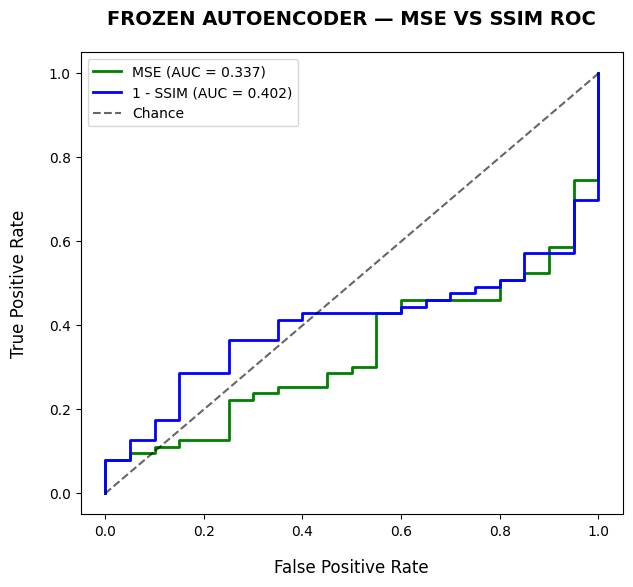

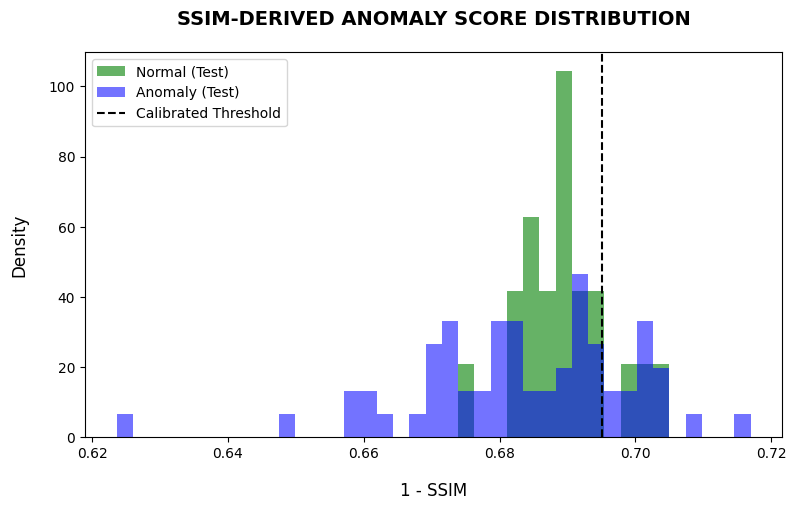


SSIM PER-DEFECT FINAL TEST ANALYSIS


,defect_category,defect_samples,ssim_roc_auc_vs_good,ssim_detection_rate_at_threshold
0,broken_large,20,0.167500,0.050000
1,broken_small,22,0.615909,0.454545
2,contamination,21,0.400000,0.333333



⚠️ SSIM RANKING DIAGNOSTIC: ROC-AUC is below 0.5 under the predefined 'higher 1-SSIM = more anomalous' contract. The score direction is intentionally not reversed after observing the final test set.

✅ BLOCK 6 COMPLETED: MSE reference reproduced and SSIM structural evaluation completed.


In [6]:
# ==========================================================================================================================================================
# BLOCK 6: FINAL STRUCTURAL ANOMALY EVALUATION — MSE VS SSIM
# ==========================================================================================================================================================

print("OPENING FINAL STRUCTURAL EVALUATION...\n")
print("ACTION: Comparing MSE and SSIM anomaly scores on identical frozen-model reconstructions.\n")


# UPSTREAM DEPENDENCY AUDIT

_required_block_6_objects = [
    "tuned_model",
    "test_images",
    "test_labels",
    "test_categories",
    "defect_categories",
    "best_batch_size",
    "notebook2_mse_auc",
    "notebook2_contract",
    "ssim_threshold",
    "reconstruction_mse",
    "batch_ssim_scores",
]

_missing_block_6_objects = [
    object_name
    for object_name in _required_block_6_objects
    if object_name not in globals() or globals()[object_name] is None
]

if _missing_block_6_objects:
    raise RuntimeError(
        "BLOCK 6 DEPENDENCY FAILURE: missing upstream objects: "
        f"{_missing_block_6_objects}. Run Blocks 1–5 first."
    )


def compute_operational_metrics(
    y_true,
    anomaly_scores,
    threshold,
):
    """Compute binary operating metrics under the shared 0=good, 1=anomaly contract."""

    predictions = (
        anomaly_scores > threshold
    ).astype(np.int8)

    matrix = confusion_matrix(
        y_true,
        predictions,
        labels=[
            NORMAL_LABEL,
            ANOMALY_LABEL,
        ],
    )

    tn, fp, fn, tp = matrix.ravel()

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        predictions,
        average="binary",
        pos_label=ANOMALY_LABEL,
        zero_division=0,
    )

    false_positive_rate = fp / max(
        fp + tn,
        1,
    )

    return {
        "roc_auc": float(
            roc_auc_score(
                y_true,
                anomaly_scores,
            )
        ),
        "threshold": float(threshold),
        "balanced_accuracy": float(
            balanced_accuracy_score(
                y_true,
                predictions,
            )
        ),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "test_false_positive_rate": float(false_positive_rate),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


# ONE FROZEN-MODEL INFERENCE PASS

test_reconstructions = tuned_model.predict(
    test_images,
    batch_size=best_batch_size,
    verbose=0,
)


# PIXEL-WISE MSE SCORE

test_mse_scores = reconstruction_mse(
    test_images,
    test_reconstructions,
)

mse_auc = float(
    roc_auc_score(
        test_labels,
        test_mse_scores,
    )
)


# CROSS-NOTEBOOK REPRODUCIBILITY GATE

if not np.isclose(
    mse_auc,
    notebook2_mse_auc,
    atol=1e-6,
    rtol=0.0,
):
    raise RuntimeError(
        "BLOCK 6 REPRODUCIBILITY FAILURE: Notebook 3 MSE ROC-AUC does not reproduce "
        f"Notebook 2. Recomputed={mse_auc:.8f}, Notebook2={notebook2_mse_auc:.8f}"
    )


# FROZEN NOTEBOOK 2 OPERATIONAL METRICS
# These are imported rather than recalibrated or recomputed from final-test observations,
# preserving the exact Notebook 2 operating point.

notebook2_model_metrics = notebook2_contract.get(
    "model_metrics",
    {},
)

required_mse_metric_keys = [
    "roc_auc",
    "threshold",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "test_false_positive_rate",
]

missing_mse_metric_keys = [
    key
    for key in required_mse_metric_keys
    if key not in notebook2_model_metrics
]

if missing_mse_metric_keys:
    raise RuntimeError(
        "BLOCK 6 UPSTREAM METRIC FAILURE: Notebook 2 contract is missing "
        f"required operational metrics: {missing_mse_metric_keys}"
    )

mse_operational_metrics = {
    key: float(
        notebook2_model_metrics[
            key
        ]
    )
    for key in required_mse_metric_keys
}

if not np.isclose(
    mse_operational_metrics[
        "roc_auc"
    ],
    mse_auc,
    atol=1e-6,
    rtol=0.0,
):
    raise RuntimeError(
        "BLOCK 6 UPSTREAM METRIC FAILURE: Notebook 2 operational ROC-AUC "
        "does not match the reproduced MSE ROC-AUC."
    )


# STRUCTURAL SSIM SCORE

test_ssim_similarity = batch_ssim_scores(
    test_images,
    test_reconstructions,
)

test_ssim_anomaly = (
    1.0
    - test_ssim_similarity
)

if np.any(test_ssim_anomaly < 0.0):
    raise RuntimeError(
        "BLOCK 6 SSIM FAILURE: negative SSIM anomaly scores detected."
    )


ssim_metrics = compute_operational_metrics(
    test_labels,
    test_ssim_anomaly,
    ssim_threshold,
)

ssim_auc = float(
    ssim_metrics["roc_auc"]
)



# UNIFIED OPERATIONAL COMPARISON
# Same frozen model and final-test set; thresholds remain those independently
# calibrated in their originating development protocols.

operational_comparison_df = pd.DataFrame(
    [
        {
            "anomaly_score": "Reconstruction MSE",
            "roc_auc": mse_operational_metrics["roc_auc"],
            "calibrated_threshold": mse_operational_metrics["threshold"],
            "balanced_accuracy": mse_operational_metrics["balanced_accuracy"],
            "precision": mse_operational_metrics["precision"],
            "recall": mse_operational_metrics["recall"],
            "f1": mse_operational_metrics["f1"],
            "test_false_positive_rate": mse_operational_metrics["test_false_positive_rate"],
            "threshold_source": "Notebook 2 independent normal calibration",
        },
        {
            "anomaly_score": "1 - SSIM",
            "roc_auc": ssim_metrics["roc_auc"],
            "calibrated_threshold": ssim_metrics["threshold"],
            "balanced_accuracy": ssim_metrics["balanced_accuracy"],
            "precision": ssim_metrics["precision"],
            "recall": ssim_metrics["recall"],
            "f1": ssim_metrics["f1"],
            "test_false_positive_rate": ssim_metrics["test_false_positive_rate"],
            "threshold_source": "Notebook 3 reproduced normal calibration subset",
        },
    ]
).set_index(
    "anomaly_score"
)

print(
    "\nMSE VS SSIM — OPERATIONAL COMPARISON"
)

display(
    operational_comparison_df
)


# ROC CURVES

mse_fpr, mse_tpr, _ = roc_curve(
    test_labels,
    test_mse_scores,
)

ssim_fpr, ssim_tpr, _ = roc_curve(
    test_labels,
    test_ssim_anomaly,
)


metric_comparison_df = pd.DataFrame(
    [
        {
            "anomaly_score": "Reconstruction MSE",
            "model": "Frozen Tuned Conv AE",
            "roc_auc": mse_auc,
            "reference": "Notebook 2",
        },
        {
            "anomaly_score": "1 - SSIM",
            "model": "Frozen Tuned Conv AE",
            "roc_auc": ssim_auc,
            "reference": "Notebook 3",
        },
    ]
)

metric_comparison_df[
    "delta_vs_mse"
] = (
    metric_comparison_df["roc_auc"]
    - mse_auc
)

print("CONTROLLED SCORE-METRIC COMPARISON")
display(metric_comparison_df)


print("\nSSIM OPERATIONAL METRICS")
display(
    pd.DataFrame(
        [
            {
                "model": "Frozen Tuned Conv AE + SSIM",
                **ssim_metrics,
            }
        ]
    ).set_index("model")
)


# NORMAL VS ANOMALY SCORE SUMMARY

normal_mask = (
    test_labels == NORMAL_LABEL
)

anomaly_mask = (
    test_labels == ANOMALY_LABEL
)


ssim_score_summary = pd.DataFrame(
    [
        {
            "group": "Normal (Test)",
            "samples": int(np.sum(normal_mask)),
            "mean_ssim_similarity": float(np.mean(test_ssim_similarity[normal_mask])),
            "median_ssim_similarity": float(np.median(test_ssim_similarity[normal_mask])),
            "mean_ssim_anomaly": float(np.mean(test_ssim_anomaly[normal_mask])),
            "median_ssim_anomaly": float(np.median(test_ssim_anomaly[normal_mask])),
        },
        {
            "group": "Anomaly (Test)",
            "samples": int(np.sum(anomaly_mask)),
            "mean_ssim_similarity": float(np.mean(test_ssim_similarity[anomaly_mask])),
            "median_ssim_similarity": float(np.median(test_ssim_similarity[anomaly_mask])),
            "mean_ssim_anomaly": float(np.mean(test_ssim_anomaly[anomaly_mask])),
            "median_ssim_anomaly": float(np.median(test_ssim_anomaly[anomaly_mask])),
        },
    ]
)

print("\nSSIM FINAL TEST SCORE DIAGNOSTIC")
display(ssim_score_summary)


# COMBINED ROC VISUALIZATION

plt.figure(
    figsize=(7, 6)
)

plt.plot(
    mse_fpr,
    mse_tpr,
    color="green",
    linewidth=2,
    label=f"MSE (AUC = {mse_auc:.3f})",
)

plt.plot(
    ssim_fpr,
    ssim_tpr,
    color="blue",
    linewidth=2,
    label=f"1 - SSIM (AUC = {ssim_auc:.3f})",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    alpha=0.6,
    label="Chance",
)

plt.title(
    "FROZEN AUTOENCODER — MSE VS SSIM ROC",
    fontsize=14,
    fontweight="bold",
    pad=20,
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12,
    labelpad=15,
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12,
    labelpad=15,
)

plt.legend()
plt.show()


# SSIM ANOMALY-SCORE DISTRIBUTION

score_min = float(
    np.min(test_ssim_anomaly)
)

score_max = float(
    np.max(test_ssim_anomaly)
)

score_bins = np.linspace(
    score_min,
    score_max,
    40,
)

plt.figure(
    figsize=(9, 5)
)

plt.hist(
    test_ssim_anomaly[normal_mask],
    bins=score_bins,
    density=True,
    alpha=0.60,
    color="green",
    label="Normal (Test)",
)

plt.hist(
    test_ssim_anomaly[anomaly_mask],
    bins=score_bins,
    density=True,
    alpha=0.55,
    color="blue",
    label="Anomaly (Test)",
)

plt.axvline(
    ssim_threshold,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Calibrated Threshold",
)

plt.title(
    "SSIM-DERIVED ANOMALY SCORE DISTRIBUTION",
    fontsize=14,
    fontweight="bold",
    pad=20,
)

plt.xlabel(
    "1 - SSIM",
    fontsize=12,
    labelpad=15,
)

plt.ylabel(
    "Density",
    fontsize=12,
    labelpad=15,
)

plt.legend()
plt.show()


# PER-DEFECT SSIM ANALYSIS

reference_good_scores = test_ssim_anomaly[
    test_categories == "good"
]

per_defect_rows = []


for category in defect_categories:

    defect_scores = test_ssim_anomaly[
        test_categories == category
    ]

    category_labels = np.concatenate(
        (
            np.full(
                len(reference_good_scores),
                NORMAL_LABEL,
                dtype=np.int8,
            ),
            np.full(
                len(defect_scores),
                ANOMALY_LABEL,
                dtype=np.int8,
            ),
        )
    )

    category_scores = np.concatenate(
        (
            reference_good_scores,
            defect_scores,
        )
    )

    per_defect_rows.append(
        {
            "defect_category": category,
            "defect_samples": int(len(defect_scores)),
            "ssim_roc_auc_vs_good": float(
                roc_auc_score(
                    category_labels,
                    category_scores,
                )
            ),
            "ssim_detection_rate_at_threshold": float(
                np.mean(
                    defect_scores > ssim_threshold
                )
            ),
        }
    )


ssim_per_defect_metrics = pd.DataFrame(
    per_defect_rows
)

print("\nSSIM PER-DEFECT FINAL TEST ANALYSIS")
display(ssim_per_defect_metrics)


ranking_inversion_observed = bool(
    ssim_auc < 0.5
)

if ranking_inversion_observed:
    print(
        "\n⚠️ SSIM RANKING DIAGNOSTIC: ROC-AUC is below 0.5 under the predefined "
        "'higher 1-SSIM = more anomalous' contract. The score direction is intentionally "
        "not reversed after observing the final test set."
    )


print(
    "\n✅ BLOCK 6 COMPLETED: MSE reference reproduced and SSIM structural evaluation completed."
)


### BLOCK 7: SSIM METRIC SENSITIVITY CONTROL

**OBJECTIVE:**  
Retain the useful idea from the original Notebook 3: characterize how SSIM responds to controlled image degradations.

This is now a **secondary metric diagnostic**, not the main anomaly-detection experiment and not an arbitrary augmentation pass/fail gate.

**IMPROVEMENTS OVER THE ORIGINAL SINGLE-IMAGE TEST:**
- multiple deterministic normal development samples instead of one hand-picked image;
- aggregate mean and standard deviation across samples;
- controlled Gaussian-noise and brightness sweeps;
- no universal `SSIM = 0.5` “safety threshold” is assumed.

The purpose is to understand SSIM sensitivity to acquisition perturbations and to document metric behavior that may matter in industrial imaging conditions.


EXECUTING SSIM SENSITIVITY CONTROL...

ACTION: Measuring SSIM response to controlled Gaussian-noise and illumination perturbations across normal development samples.

SSIM SENSITIVITY SUMMARY


,perturbation,parameter,value,samples,mean_ssim,std_ssim,min_ssim,max_ssim
0,Gaussian Noise,variance,0.001,12,0.819602,0.002582,0.814031,0.823246
1,Gaussian Noise,variance,0.002,12,0.721156,0.004556,0.711209,0.728378
2,Gaussian Noise,variance,0.005,12,0.566498,0.005948,0.555974,0.575235
3,Gaussian Noise,variance,0.010,12,0.449696,0.006504,0.438547,0.461833
4,Gaussian Noise,variance,0.020,12,0.345531,0.005229,0.336012,0.355246
5,Gaussian Noise,variance,0.050,12,0.231227,0.005661,0.221490,0.238745
6,Gaussian Noise,variance,0.100,12,0.163478,0.004251,0.156300,0.172358
7,Brightness,factor,1.000,12,1.000000,0.000000,1.000000,1.000000
8,Brightness,factor,0.900,12,0.991131,0.000024,0.991086,0.991165
9,Brightness,factor,0.800,12,0.961319,0.000105,0.961118,0.961468


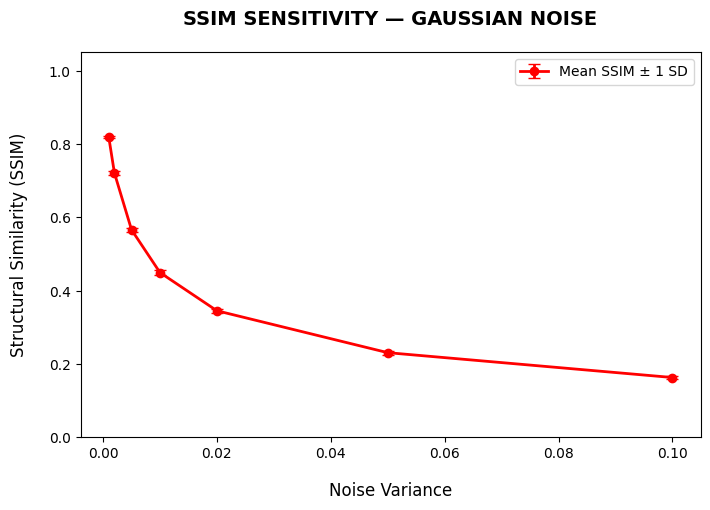

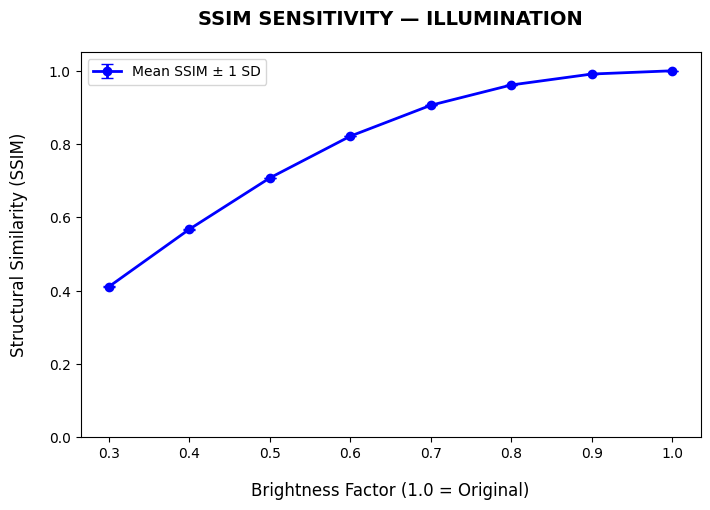


NOTE: These curves characterize SSIM metric sensitivity. They do not define a universal augmentation safety threshold and are not used to tune the final test evaluation.

✅ BLOCK 7 COMPLETED: Multi-sample SSIM sensitivity control completed.


In [7]:
# ==========================================================================================================================================================
# BLOCK 7: SSIM METRIC SENSITIVITY CONTROL
# ==========================================================================================================================================================

print("EXECUTING SSIM SENSITIVITY CONTROL...\n")
print("ACTION: Measuring SSIM response to controlled Gaussian-noise and illumination perturbations across normal development samples.\n")


# UPSTREAM DEPENDENCY AUDIT

_required_block_7_objects = [
    "tuning_validation_images",
    "NOISE_VARIANCES",
    "BRIGHTNESS_FACTORS",
    "SENSITIVITY_SAMPLE_COUNT",
    "SEED",
]

_missing_block_7_objects = [
    object_name
    for object_name in _required_block_7_objects
    if object_name not in globals() or globals()[object_name] is None
]

if _missing_block_7_objects:
    raise RuntimeError(
        "BLOCK 7 DEPENDENCY FAILURE: missing upstream objects: "
        f"{_missing_block_7_objects}. Run the notebook sequentially from Block 1."
    )


def add_gaussian_noise(
    image,
    variance,
    rng,
):
    """Add zero-mean Gaussian noise to one normalized RGB image."""

    if variance < 0.0:
        raise ValueError(
            "Gaussian-noise variance must be non-negative."
        )

    noise = rng.normal(
        loc=0.0,
        scale=np.sqrt(variance),
        size=image.shape,
    ).astype(np.float32)

    return np.clip(
        image + noise,
        0.0,
        1.0,
    ).astype(
        np.float32,
        copy=False,
    )


def adjust_brightness(
    image,
    factor,
):
    """Apply multiplicative brightness scaling to one normalized RGB image."""

    if factor < 0.0:
        raise ValueError(
            "Brightness factor must be non-negative."
        )

    return np.clip(
        image * factor,
        0.0,
        1.0,
    ).astype(
        np.float32,
        copy=False,
    )


# DETERMINISTIC MULTI-SAMPLE REFERENCE SET

n_sensitivity_samples = min(
    SENSITIVITY_SAMPLE_COUNT,
    len(tuning_validation_images),
)

rng_selection = np.random.default_rng(
    SEED + 30
)

sensitivity_indices = rng_selection.choice(
    len(tuning_validation_images),
    size=n_sensitivity_samples,
    replace=False,
)

sensitivity_images = tuning_validation_images[
    sensitivity_indices
]


sensitivity_rows = []


# GAUSSIAN-NOISE SWEEP

for level_index, variance in enumerate(NOISE_VARIANCES):

    level_scores = []

    for sample_index, image in enumerate(sensitivity_images):

        rng_noise = np.random.default_rng(
            SEED
            + 1000 * level_index
            + sample_index
        )

        degraded = add_gaussian_noise(
            image,
            variance=variance,
            rng=rng_noise,
        )

        level_scores.append(
            ssim_similarity_score(
                image,
                degraded,
            )
        )

    sensitivity_rows.append(
        {
            "perturbation": "Gaussian Noise",
            "parameter": "variance",
            "value": float(variance),
            "samples": int(len(level_scores)),
            "mean_ssim": float(np.mean(level_scores)),
            "std_ssim": float(np.std(level_scores)),
            "min_ssim": float(np.min(level_scores)),
            "max_ssim": float(np.max(level_scores)),
        }
    )


# BRIGHTNESS SWEEP

for factor in BRIGHTNESS_FACTORS:

    level_scores = []

    for image in sensitivity_images:

        degraded = adjust_brightness(
            image,
            factor=factor,
        )

        level_scores.append(
            ssim_similarity_score(
                image,
                degraded,
            )
        )

    sensitivity_rows.append(
        {
            "perturbation": "Brightness",
            "parameter": "factor",
            "value": float(factor),
            "samples": int(len(level_scores)),
            "mean_ssim": float(np.mean(level_scores)),
            "std_ssim": float(np.std(level_scores)),
            "min_ssim": float(np.min(level_scores)),
            "max_ssim": float(np.max(level_scores)),
        }
    )


ssim_sensitivity_results = pd.DataFrame(
    sensitivity_rows
)

print("SSIM SENSITIVITY SUMMARY")
display(ssim_sensitivity_results)


# SENSITIVITY CURVES

noise_df = ssim_sensitivity_results[
    ssim_sensitivity_results["perturbation"] == "Gaussian Noise"
].copy()

brightness_df = ssim_sensitivity_results[
    ssim_sensitivity_results["perturbation"] == "Brightness"
].copy()


plt.figure(
    figsize=(8, 5)
)

plt.errorbar(
    noise_df["value"],
    noise_df["mean_ssim"],
    yerr=noise_df["std_ssim"],
    marker="o",
    linewidth=2,
    capsize=4,
    color="red",
    label="Mean SSIM ± 1 SD",
)

plt.title(
    "SSIM SENSITIVITY — GAUSSIAN NOISE",
    fontsize=14,
    fontweight="bold",
    pad=20,
)

plt.xlabel(
    "Noise Variance",
    fontsize=12,
    labelpad=15,
)

plt.ylabel(
    "Structural Similarity (SSIM)",
    fontsize=12,
    labelpad=15,
)

plt.ylim(
    0.0,
    1.05,
)

plt.legend()
plt.show()


plt.figure(
    figsize=(8, 5)
)

plt.errorbar(
    brightness_df["value"],
    brightness_df["mean_ssim"],
    yerr=brightness_df["std_ssim"],
    marker="o",
    linewidth=2,
    capsize=4,
    color="blue",
    label="Mean SSIM ± 1 SD",
)

plt.title(
    "SSIM SENSITIVITY — ILLUMINATION",
    fontsize=14,
    fontweight="bold",
    pad=20,
)

plt.xlabel(
    "Brightness Factor (1.0 = Original)",
    fontsize=12,
    labelpad=15,
)

plt.ylabel(
    "Structural Similarity (SSIM)",
    fontsize=12,
    labelpad=15,
)

plt.ylim(
    0.0,
    1.05,
)

plt.legend()
plt.show()


print(
    "\nNOTE: These curves characterize SSIM metric sensitivity. They do not define a universal "
    "augmentation safety threshold and are not used to tune the final test evaluation."
)

print(
    "\n✅ BLOCK 7 COMPLETED: Multi-sample SSIM sensitivity control completed."
)


### BLOCK 8: QUALITATIVE STRUCTURAL DIFFERENCE ANALYSIS

**OBJECTIVE:**  
Visualize how the frozen autoencoder's reconstructions differ structurally from representative normal and defective final-test images.

**DISPLAY CONTRACT:**
- one deterministic normal example;
- one deterministic example from each defect category;
- `Original | Reconstruction | Structural Difference`;
- one shared robust display scale across all structural-difference maps.

The maps are **qualitative structural-difference visualizations**. They are not presented as pixel-accurate defect localization unless separately validated against MVTec ground-truth masks.


GENERATING QUALITATIVE STRUCTURAL ANALYSIS...

ACTION: Comparing original images, frozen-model reconstructions and SSIM-derived structural-difference maps.



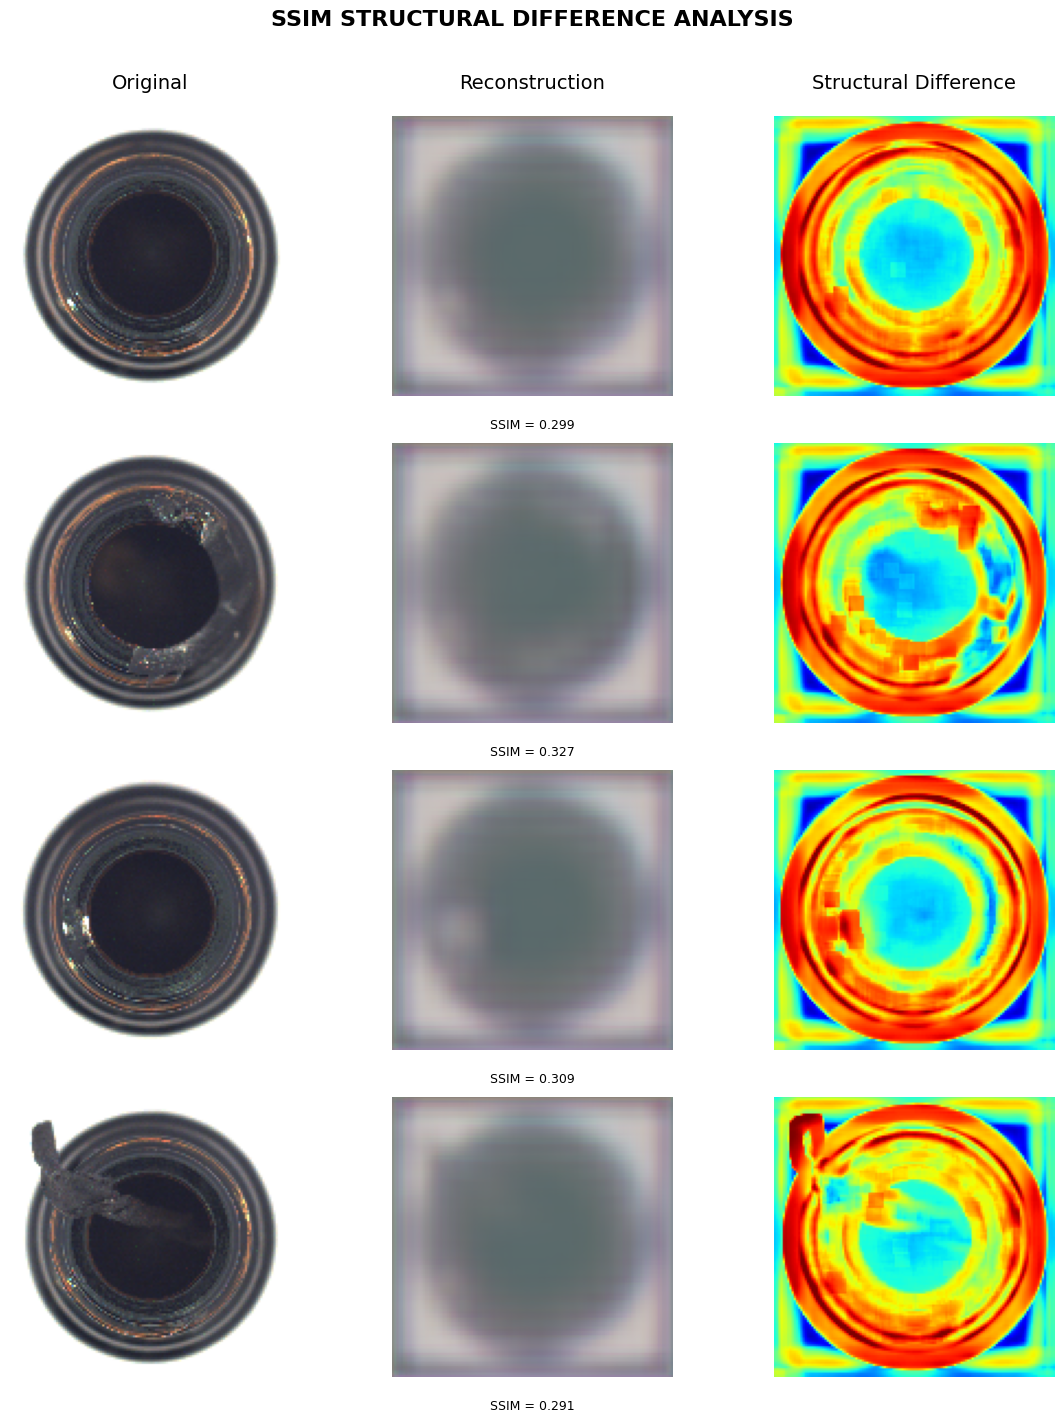

,category,ssim_similarity,ssim_anomaly_score
0,Good,0.298852,0.701148
1,Broken Large,0.327458,0.672542
2,Broken Small,0.309062,0.690938
3,Contamination,0.291438,0.708562



NOTE: All structural-difference maps share the same robust display scale. They are qualitative diagnostics, not validated pixel-level localization masks.

✅ BLOCK 8 COMPLETED: Representative structural-difference analysis generated.


In [8]:
# ==========================================================================================================================================================
# BLOCK 8: QUALITATIVE STRUCTURAL DIFFERENCE ANALYSIS
# ==========================================================================================================================================================

print("GENERATING QUALITATIVE STRUCTURAL ANALYSIS...\n")
print("ACTION: Comparing original images, frozen-model reconstructions and SSIM-derived structural-difference maps.\n")


# UPSTREAM DEPENDENCY AUDIT

_required_block_8_objects = [
    "test_good",
    "test_bad",
    "test_bad_categories",
    "test_reconstructions",
    "test_labels",
    "ssim_similarity_score",
    "RESIDUAL_DISPLAY_QUANTILE",
    "SEED",
]

_missing_block_8_objects = [
    object_name
    for object_name in _required_block_8_objects
    if object_name not in globals() or globals()[object_name] is None
]

if _missing_block_8_objects:
    raise RuntimeError(
        "BLOCK 8 DEPENDENCY FAILURE: missing upstream objects: "
        f"{_missing_block_8_objects}. Run Blocks 1–6 first."
    )


# ALIGN FINAL-TEST RECONSTRUCTIONS WITH NORMAL / ANOMALOUS GROUPS

normal_mask = (
    test_labels == NORMAL_LABEL
)

anomaly_mask = (
    test_labels == ANOMALY_LABEL
)

good_reconstructions = test_reconstructions[
    normal_mask
]

bad_reconstructions = test_reconstructions[
    anomaly_mask
]


if len(good_reconstructions) != len(test_good):
    raise RuntimeError(
        "BLOCK 8 ALIGNMENT FAILURE: normal reconstructions are misaligned."
    )

if len(bad_reconstructions) != len(test_bad):
    raise RuntimeError(
        "BLOCK 8 ALIGNMENT FAILURE: anomalous reconstructions are misaligned."
    )


# REPRESENTATIVE SAMPLE SELECTION

rng_visual = np.random.default_rng(
    SEED + 40
)

representatives = []


good_index = int(
    rng_visual.integers(
        0,
        len(test_good),
    )
)

representatives.append(
    {
        "category": "Good",
        "original": test_good[good_index],
        "reconstruction": good_reconstructions[good_index],
    }
)


for category in sorted(
    np.unique(test_bad_categories)
):

    category_indices = np.flatnonzero(
        test_bad_categories == category
    )

    sample_index = int(
        rng_visual.choice(
            category_indices
        )
    )

    representatives.append(
        {
            "category": str(category).replace("_", " ").title(),
            "original": test_bad[sample_index],
            "reconstruction": bad_reconstructions[sample_index],
        }
    )


# STRUCTURAL DIFFERENCE MAPS

difference_maps = []

for representative in representatives:

    similarity_score, difference_map = ssim_similarity_score(
        representative["original"],
        representative["reconstruction"],
        return_map=True,
    )

    representative["ssim_similarity"] = similarity_score
    representative["ssim_anomaly"] = 1.0 - similarity_score

    difference_maps.append(
        difference_map
    )


shared_vmax = float(
    np.quantile(
        np.concatenate(
            [
                difference_map.ravel()
                for difference_map in difference_maps
            ]
        ),
        RESIDUAL_DISPLAY_QUANTILE,
    )
)

shared_vmax = max(
    shared_vmax,
    np.finfo(np.float32).eps,
)


# VISUALIZATION

n_rows = len(
    representatives
)

plt.figure(
    figsize=(
        12,
        3.5 * n_rows,
    )
)

plt.suptitle(
    "SSIM STRUCTURAL DIFFERENCE ANALYSIS",
    fontsize=16,
    fontweight="bold",
    y=1.01,
)


for row_index, representative in enumerate(representatives):

    original = representative[
        "original"
    ]

    reconstruction = representative[
        "reconstruction"
    ]

    difference_map = difference_maps[
        row_index
    ]


    ax = plt.subplot(
        n_rows,
        3,
        row_index * 3 + 1,
    )

    ax.imshow(
        original
    )

    if row_index == 0:
        ax.set_title(
            "Original",
            fontsize=14,
            pad=20,
        )

    ax.set_ylabel(
        representative["category"],
        fontsize=11,
        labelpad=12,
    )

    ax.axis("off")


    ax = plt.subplot(
        n_rows,
        3,
        row_index * 3 + 2,
    )

    ax.imshow(
        reconstruction
    )

    if row_index == 0:
        ax.set_title(
            "Reconstruction",
            fontsize=14,
            pad=20,
        )

    ax.text(
        0.5,
        -0.08,
        f"SSIM = {representative['ssim_similarity']:.3f}",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=9,
    )

    ax.axis("off")


    ax = plt.subplot(
        n_rows,
        3,
        row_index * 3 + 3,
    )

    ax.imshow(
        difference_map,
        cmap="jet",
        vmin=0.0,
        vmax=shared_vmax,
    )

    if row_index == 0:
        ax.set_title(
            "Structural Difference",
            fontsize=14,
            pad=20,
        )

    ax.axis("off")


plt.tight_layout()
plt.show()


qualitative_summary = pd.DataFrame(
    [
        {
            "category": representative["category"],
            "ssim_similarity": float(representative["ssim_similarity"]),
            "ssim_anomaly_score": float(representative["ssim_anomaly"]),
        }
        for representative in representatives
    ]
)

display(
    qualitative_summary
)

print(
    "\nNOTE: All structural-difference maps share the same robust display scale. "
    "They are qualitative diagnostics, not validated pixel-level localization masks."
)

print(
    "\n✅ BLOCK 8 COMPLETED: Representative structural-difference analysis generated."
)


### BLOCK 9: CONTROLLED METRIC COMPARISON & SCIENTIFIC INTERPRETATION

**OBJECTIVE:**  
Interpret what changes when the anomaly score moves from pixel-wise MSE to structural similarity while the underlying reconstruction model remains frozen.

**INTERPRETATION RULES:**
- A higher SSIM ROC-AUC is described as a **numerical improvement in structural scoring**, not proof of universal superiority.
- A lower or equal SSIM ROC-AUC is retained as evidence that changing the reconstruction metric alone did not solve the ranking limitation.
- The final-test score direction is never reversed post hoc.
- The sensitivity experiment remains diagnostic and is not used to select the final-test metric after seeing results.

This block provides the conceptual bridge from reconstruction-based analysis toward the more advanced learned representations evaluated in Notebook 4.


ASSEMBLING STRUCTURAL ANALYSIS CONCLUSION...

ACTION: Interpreting MSE vs SSIM under a frozen-model controlled comparison.



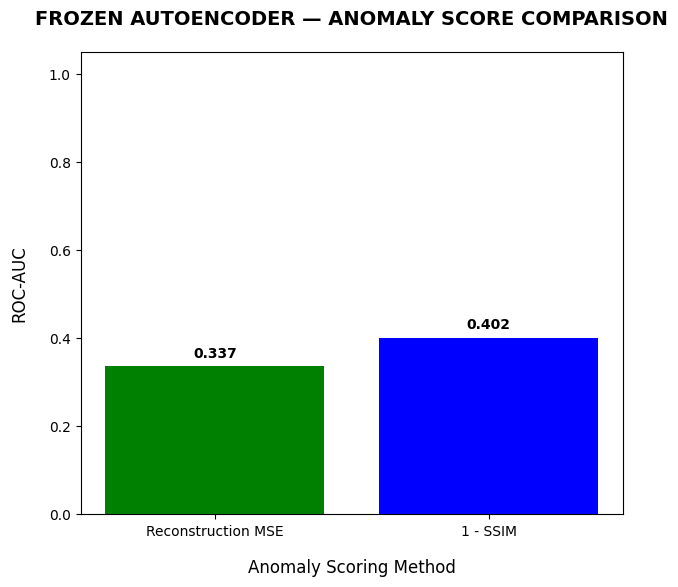

SCIENTIFIC CONCLUSION
The SSIM-derived anomaly score achieved a numerically higher ROC-AUC than reconstruction MSE by 0.0651 for the same frozen autoencoder. Because the model and reconstructions were unchanged, the observed difference isolates the effect of structural scoring rather than model retraining. The result is interpreted as experiment-scoped evidence, not as proof of universal SSIM superiority.
Additional diagnostic: the SSIM-derived score remained below chance under the locked 'higher 1-SSIM = more anomalous' contract. No post-hoc score reversal was applied.

THESIS TRANSITION: Notebook 3 isolates the strengths and limits of reconstruction-based structural scoring. Notebook 4 can therefore evaluate whether stronger learned visual representations provide more robust anomaly discrimination.

✅ BLOCK 9 COMPLETED: Structural-analysis interpretation finalized.


In [9]:
# ==========================================================================================================================================================
# BLOCK 9: CONTROLLED METRIC COMPARISON & SCIENTIFIC INTERPRETATION
# ==========================================================================================================================================================

print("ASSEMBLING STRUCTURAL ANALYSIS CONCLUSION...\n")
print("ACTION: Interpreting MSE vs SSIM under a frozen-model controlled comparison.\n")


# UPSTREAM DEPENDENCY AUDIT

_required_block_9_objects = [
    "mse_auc",
    "ssim_auc",
    "ranking_inversion_observed",
]

_missing_block_9_objects = [
    object_name
    for object_name in _required_block_9_objects
    if object_name not in globals() or globals()[object_name] is None
]

if _missing_block_9_objects:
    raise RuntimeError(
        "BLOCK 9 DEPENDENCY FAILURE: missing upstream metrics: "
        f"{_missing_block_9_objects}. Run Block 6 first."
    )


comparison_plot_df = pd.DataFrame(
    [
        {
            "metric": "Reconstruction MSE",
            "roc_auc": mse_auc,
        },
        {
            "metric": "1 - SSIM",
            "roc_auc": ssim_auc,
        },
    ]
)


plt.figure(
    figsize=(7, 6)
)

bars = plt.bar(
    comparison_plot_df["metric"],
    comparison_plot_df["roc_auc"],
    color=[
        "green",
        "blue",
    ],
)

plt.title(
    "FROZEN AUTOENCODER — ANOMALY SCORE COMPARISON",
    fontsize=14,
    fontweight="bold",
    pad=20,
)

plt.xlabel(
    "Anomaly Scoring Method",
    fontsize=12,
    labelpad=15,
)

plt.ylabel(
    "ROC-AUC",
    fontsize=12,
    labelpad=15,
)

plt.ylim(
    0.0,
    1.05,
)

for bar in bars:

    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center",
        fontweight="bold",
    )

plt.show()


ssim_delta = (
    ssim_auc
    - mse_auc
)


print("SCIENTIFIC CONCLUSION")


if np.isclose(
    ssim_delta,
    0.0,
    atol=1e-6,
):

    conclusion = (
        "The SSIM-derived anomaly score matched the reconstruction-MSE ROC-AUC "
        "within numerical precision for the same frozen autoencoder. "
        "Changing the reconstruction metric therefore did not materially alter anomaly ranking "
        "in this fixed experiment."
    )


elif ssim_delta > 0.0:

    conclusion = (
        f"The SSIM-derived anomaly score achieved a numerically higher ROC-AUC than reconstruction MSE "
        f"by {ssim_delta:.4f} for the same frozen autoencoder. "
        "Because the model and reconstructions were unchanged, the observed difference isolates the effect "
        "of structural scoring rather than model retraining. "
        "The result is interpreted as experiment-scoped evidence, not as proof of universal SSIM superiority."
    )


else:

    conclusion = (
        f"The SSIM-derived anomaly score achieved a numerically lower ROC-AUC than reconstruction MSE "
        f"by {abs(ssim_delta):.4f} for the same frozen autoencoder. "
        "The structural metric therefore did not resolve the anomaly-ranking limitation in this fixed experiment. "
        "The result is retained without post-hoc metric inversion or final-test-driven redesign."
    )


print(
    conclusion
)


if ranking_inversion_observed:

    print(
        "Additional diagnostic: the SSIM-derived score remained below chance under the locked "
        "'higher 1-SSIM = more anomalous' contract. No post-hoc score reversal was applied."
    )


print(
    "\nTHESIS TRANSITION: Notebook 3 isolates the strengths and limits of reconstruction-based structural scoring. "
    "Notebook 4 can therefore evaluate whether stronger learned visual representations provide more robust anomaly discrimination."
)

print(
    "\n✅ BLOCK 9 COMPLETED: Structural-analysis interpretation finalized."
)


### BLOCK 10: SSIM METRIC & ANALYSIS EXPORT

**OBJECTIVE:**  
Persist the Notebook 3 structural-analysis evidence in a portable cross-notebook contract.

**EXPORTED ARTIFACTS:**
- final MSE-vs-SSIM ROC-AUC comparison (`.csv`);
- MSE-vs-SSIM operational metric comparison (`.csv`);
- SSIM final-test score summary (`.csv`);
- SSIM per-defect evaluation (`.csv`);
- multi-sample SSIM sensitivity results (`.csv`);
- Notebook 3 metric contract (`notebook3_metrics.json`).

**OWNERSHIP POLICY:**  
The tuned model remains owned by Notebook 2 and is **not duplicated** as a Notebook 3 artifact. Notebook 3 exports structural-analysis results only.

The top-level key `ssim` provides the canonical Notebook 3 ROC-AUC for later thesis comparisons.


In [10]:
# ==========================================================================================================================================================
# BLOCK 10: SSIM METRIC & ANALYSIS EXPORT
# ==========================================================================================================================================================

print("EXPORTING NOTEBOOK 3 STRUCTURAL ANALYSIS ARTIFACTS...\n")
print("ACTION: Persisting SSIM metrics, diagnostics, sensitivity evidence and the cross-notebook contract.\n")


# UPSTREAM DEPENDENCY AUDIT

_required_block_10_objects = [
    "mse_auc",
    "ssim_auc",
    "ssim_metrics",
    "ssim_threshold",
    "ssim_calibration_flag_rate",
    "ranking_inversion_observed",
    "metric_comparison_df",
    "operational_comparison_df",
    "ssim_score_summary",
    "ssim_per_defect_metrics",
    "ssim_sensitivity_results",
    "notebook2_contract",
    "NOTEBOOK2_METRICS_PATH",
    "NOTEBOOK3_ARTIFACT_DIR",
    "NOTEBOOK3_METRICS_PATH",
    "TARGET_CLASS",
    "IMG_SIZE",
    "SEED",
    "train_images",
    "validation_images",
    "tuning_validation_images",
    "calibration_images",
    "test_good",
    "test_bad",
    "test_bad_categories",
]

_missing_block_10_objects = [
    object_name
    for object_name in _required_block_10_objects
    if object_name not in globals() or globals()[object_name] is None
]

if _missing_block_10_objects:
    raise RuntimeError(
        "BLOCK 10 DEPENDENCY FAILURE: missing upstream objects: "
        f"{_missing_block_10_objects}. Run the notebook sequentially from Block 1."
    )


# ARTIFACT PATHS

NOTEBOOK3_ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

METRIC_COMPARISON_PATH = (
    NOTEBOOK3_ARTIFACT_DIR
    / "mse_vs_ssim_metrics.csv"
)


OPERATIONAL_COMPARISON_PATH = (
    NOTEBOOK3_ARTIFACT_DIR
    / "mse_vs_ssim_operational_metrics.csv"
)

SSIM_SCORE_SUMMARY_PATH = (
    NOTEBOOK3_ARTIFACT_DIR
    / "ssim_test_score_summary.csv"
)

SSIM_PER_DEFECT_PATH = (
    NOTEBOOK3_ARTIFACT_DIR
    / "ssim_per_defect_metrics.csv"
)

SSIM_SENSITIVITY_PATH = (
    NOTEBOOK3_ARTIFACT_DIR
    / "ssim_sensitivity_results.csv"
)


# CSV EXPORT

metric_comparison_df.to_csv(
    METRIC_COMPARISON_PATH,
    index=False,
)


operational_comparison_df.reset_index().to_csv(
    OPERATIONAL_COMPARISON_PATH,
    index=False,
)

ssim_score_summary.to_csv(
    SSIM_SCORE_SUMMARY_PATH,
    index=False,
)

ssim_per_defect_metrics.to_csv(
    SSIM_PER_DEFECT_PATH,
    index=False,
)

ssim_sensitivity_results.to_csv(
    SSIM_SENSITIVITY_PATH,
    index=False,
)


def to_portable_relative_path(
    path
):
    """Return an artifact path relative to the directory containing notebook3_metrics.json."""

    path = Path(
        path
    )

    try:
        return path.relative_to(
            NOTEBOOK3_METRICS_PATH.parent
        ).as_posix()

    except ValueError as exc:
        raise RuntimeError(
            "BLOCK 10 PATH FAILURE: exported artifact lies outside the metrics-contract directory: "
            f"{path}"
        ) from exc


defect_sample_counts = {
    str(category): int(
        np.sum(
            test_bad_categories == category
        )
    )
    for category in sorted(
        np.unique(
            test_bad_categories
        )
    )
}


notebook3_metrics = {
    "schema_version": "1.0",

    "experiment_role": "ssim_structural_reconstruction_analysis",

    "target_class": TARGET_CLASS,

    "img_size": list(
        IMG_SIZE
    ),

    "seed": SEED,

    "label_contract": {
        "good": NORMAL_LABEL,
        "anomaly": ANOMALY_LABEL,
    },

    "score_contract": (
        "higher_score_means_more_anomalous"
    ),

    "ssim_similarity_contract": (
        "higher_similarity_means_more_structurally_similar"
    ),

    "ssim_anomaly_score_definition": (
        "1_minus_ssim"
    ),

    "score_direction_locked_before_test": True,

    # Canonical downstream Notebook 3 comparison key.
    "ssim": float(
        ssim_auc
    ),

    "upstream_notebook2": {
        "source_metrics_filename": NOTEBOOK2_METRICS_PATH.name,
        "source_schema_version": notebook2_contract["schema_version"],
        "model_artifact_owned_by": "Notebook 2",
        "conv_ae_mse_reference": float(
            mse_auc
        ),
    },

    "dataset_summary": {
        "train_normal": int(
            len(train_images)
        ),
        "outer_validation_normal": int(
            len(validation_images)
        ),
        "tuning_validation_normal": int(
            len(tuning_validation_images)
        ),
        "calibration_normal": int(
            len(calibration_images)
        ),
        "test_normal": int(
            len(test_good)
        ),
        "test_anomaly": int(
            len(test_bad)
        ),
        "test_defect_categories": defect_sample_counts,
    },

    "threshold_policy": {
        "source": "reproduced_notebook2_normal_calibration_subset",
        "calibration_samples": int(
            len(calibration_images)
        ),
        "target_validation_false_positive_rate": float(
            TARGET_VALIDATION_FPR
        ),
        "empirical_quantile_method": "higher",
        "decision_rule": "score > threshold",
        "threshold": float(
            ssim_threshold
        ),
        "observed_calibration_flag_rate": float(
            ssim_calibration_flag_rate
        ),
    },

    "structural_metrics": {
        **ssim_metrics,
        "mse_reference_roc_auc": float(
            mse_auc
        ),
        "ssim_delta_vs_mse": float(
            ssim_auc - mse_auc
        ),
        "ranking_inversion_observed": bool(
            ranking_inversion_observed
        ),
        "posthoc_score_reversal_applied": False,
    },

    "sensitivity_control": {
        "role": "diagnostic_only",
        "samples": int(
            min(
                SENSITIVITY_SAMPLE_COUNT,
                len(tuning_validation_images),
            )
        ),
        "noise_variances": [
            float(value)
            for value in NOISE_VARIANCES
        ],
        "brightness_factors": [
            float(value)
            for value in BRIGHTNESS_FACTORS
        ],
        "universal_ssim_safety_threshold_assumed": False,
    },

    "artifact_path_policy": (
        "paths_are_relative_to_the_directory_containing_notebook3_metrics_json"
    ),

    "artifacts": {
        "metric_comparison": to_portable_relative_path(
            METRIC_COMPARISON_PATH
        ),
        "operational_comparison": to_portable_relative_path(
            OPERATIONAL_COMPARISON_PATH
        ),
        "ssim_test_score_summary": to_portable_relative_path(
            SSIM_SCORE_SUMMARY_PATH
        ),
        "ssim_per_defect_metrics": to_portable_relative_path(
            SSIM_PER_DEFECT_PATH
        ),
        "ssim_sensitivity_results": to_portable_relative_path(
            SSIM_SENSITIVITY_PATH
        ),
    },
}


with NOTEBOOK3_METRICS_PATH.open(
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        notebook3_metrics,
        file,
        indent=2,
        sort_keys=True,
    )


# ARTIFACT VERIFICATION

artifact_paths = [
    NOTEBOOK3_METRICS_PATH,
    METRIC_COMPARISON_PATH,
    OPERATIONAL_COMPARISON_PATH,
    SSIM_SCORE_SUMMARY_PATH,
    SSIM_PER_DEFECT_PATH,
    SSIM_SENSITIVITY_PATH,
]

artifact_audit = pd.DataFrame(
    [
        {
            "artifact": path.name,
            "exists": path.is_file(),
            "size_kb": (
                round(
                    path.stat().st_size / 1024.0,
                    2,
                )
                if path.is_file()
                else np.nan
            ),
            "portable_path": (
                path.name
                if path == NOTEBOOK3_METRICS_PATH
                else to_portable_relative_path(
                    path
                )
            ),
            "runtime_path": str(
                path
            ),
        }
        for path in artifact_paths
    ]
)


if not artifact_audit["exists"].all():

    missing = artifact_audit.loc[
        ~artifact_audit["exists"],
        "artifact",
    ].tolist()

    raise RuntimeError(
        "BLOCK 10 EXPORT FAILURE: "
        f"missing artifacts: {missing}"
    )


display(
    artifact_audit
)

print(
    f"\nPrimary metrics contract: {NOTEBOOK3_METRICS_PATH}"
)

print(
    "\n✅ BLOCK 10 COMPLETED: Notebook 3 structural-analysis evidence exported successfully."
)


EXPORTING NOTEBOOK 3 STRUCTURAL ANALYSIS ARTIFACTS...

ACTION: Persisting SSIM metrics, diagnostics, sensitivity evidence and the cross-notebook contract.



,artifact,exists,size_kb,portable_path,runtime_path
0,notebook3_metrics.json,True,2.75,notebook3_metrics.json,/kaggle/working/notebook3_metrics.json
1,mse_vs_ssim_metrics.csv,True,0.20,notebook3_artifacts/mse_vs_ssim_metrics.csv,/kaggle/working/notebook3_artifacts/mse_vs_ssi...
2,mse_vs_ssim_operational_metrics.csv,True,0.46,notebook3_artifacts/mse_vs_ssim_operational_me...,/kaggle/working/notebook3_artifacts/mse_vs_ssi...
3,ssim_test_score_summary.csv,True,0.28,notebook3_artifacts/ssim_test_score_summary.csv,/kaggle/working/notebook3_artifacts/ssim_test_...
4,ssim_per_defect_metrics.csv,True,0.20,notebook3_artifacts/ssim_per_defect_metrics.csv,/kaggle/working/notebook3_artifacts/ssim_per_d...
5,ssim_sensitivity_results.csv,True,1.58,notebook3_artifacts/ssim_sensitivity_results.csv,/kaggle/working/notebook3_artifacts/ssim_sensi...



Primary metrics contract: /kaggle/working/notebook3_metrics.json

✅ BLOCK 10 COMPLETED: Notebook 3 structural-analysis evidence exported successfully.
